# Handwritten Digits Recognition using Machine Learning & Deep Learning

## Project Overview

Handwritten digit recognition is a fundamental computer vision problem where the objective is to identify handwritten numerical digits ranging from 0 to 9. This project utilizes the MNIST dataset, one of the most widely used benchmark datasets in machine learning and computer vision.

The project involves comprehensive data analysis, image preprocessing, model development, performance evaluation, and comparison of multiple classification algorithms to identify the most effective model for production deployment.

---

### Business Objective

To develop an intelligent image classification system capable of accurately recognizing handwritten digits from images and automatically categorizing them into one of ten classes (0-9).

---

### Project Goals

- Perform detailed exploratory data analysis.
- Understand image characteristics and class distribution.
- Build multiple machine learning and deep learning models.
- Compare model performances using evaluation metrics.
- Select the best-performing model for production use.
- Create a robust digit prediction system.

---

### Dataset

Dataset: MNIST Handwritten Digits Dataset

Number of Classes: 10

Target Classes:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9

Image Size:
28 × 28 Pixels

Domain:
Computer Vision
Image Classification

# Importing Required Libraries

This section imports all the necessary libraries required for data manipulation, visualization, machine learning, deep learning, and model evaluation.

The imported libraries will support:

- Data preprocessing
- Exploratory data analysis
- Image visualization
- Model building
- Model evaluation
- Deep learning implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
import warnings
warnings.filterwarnings('ignore')

# Loading MNIST Dataset

The MNIST dataset is a benchmark dataset in computer vision containing handwritten digit images.

Each image:

- Contains 28 × 28 pixels
- Represents a digit between 0 and 9
- Is stored as a grayscale image

The dataset is divided into training and testing sets.

In [5]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 512s 45us/step


# Dataset Overview

Before building machine learning models, it is important to understand the size and structure of the dataset.

This section explores:

- Number of observations
- Image dimensions
- Number of classes
- Shape of training and testing datasets

In [6]:
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


# Visualizing Sample Handwritten Digits

Visual inspection helps understand the appearance and variability of handwritten digits.

The following images represent sample observations from the dataset.

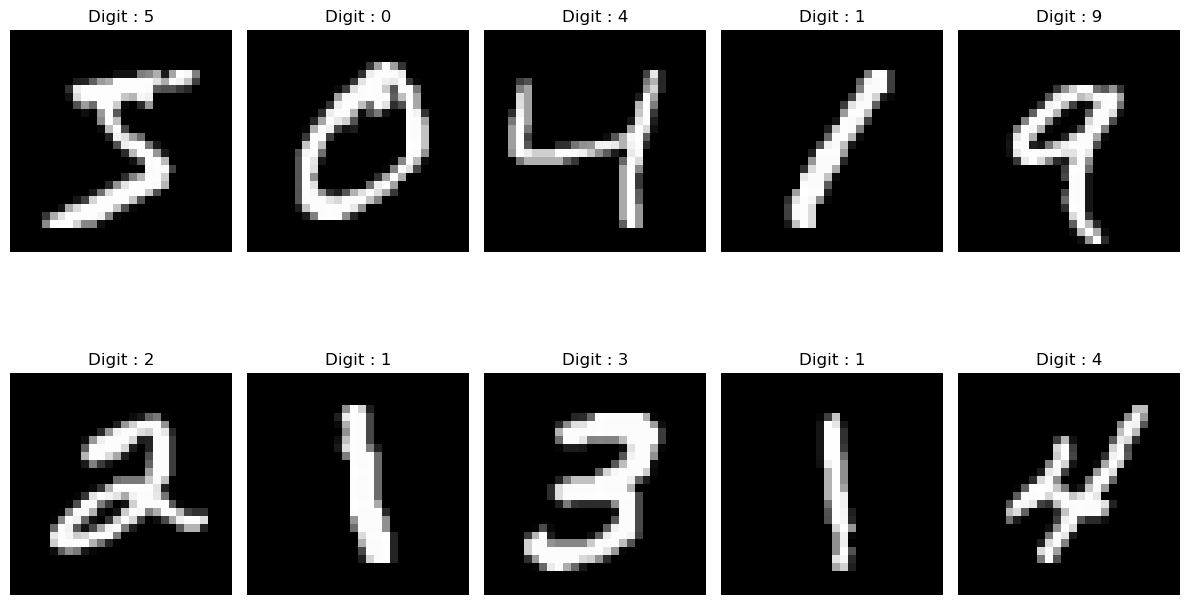

In [7]:
plt.figure(figsize=(12,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Digit : {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Class Distribution Analysis

A balanced dataset is important for building reliable classification models.

This section examines the distribution of digit classes from 0 to 9.

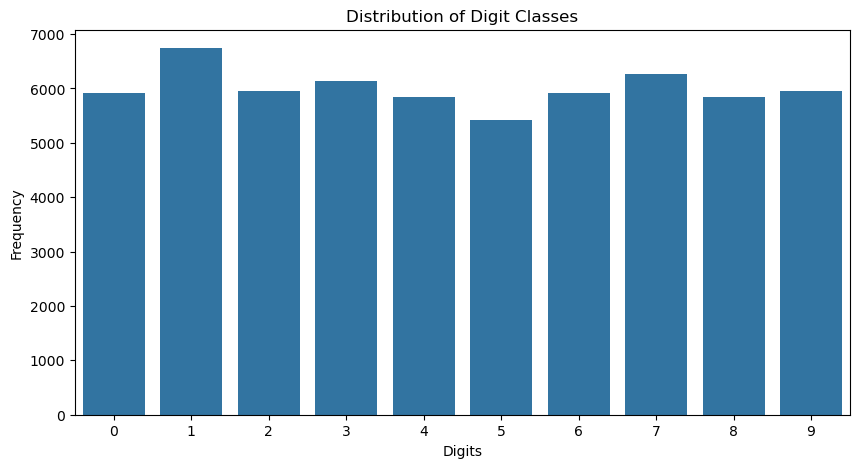

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(x=y_train)
plt.title("Distribution of Digit Classes")
plt.xlabel("Digits")
plt.ylabel("Frequency")
plt.show()

# Image Statistics Analysis

Each image in the MNIST dataset consists of grayscale pixel values ranging from 0 to 255.

Understanding pixel intensity distribution helps identify the range of values and determine appropriate preprocessing techniques.

Key Objectives:

- Analyze pixel value ranges
- Identify minimum and maximum intensity values
- Understand image representation before normalization

In [9]:
print("Minimum Pixel Value :", x_train.min())
print('Maximum Pixel Value :', x_train.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


# Data Normalization

Machine learning and deep learning models perform better when input features are scaled.

Normalization converts pixel values from the range:

0 - 255

to

0 - 1

Benefits:

- Faster model convergence
- Improved numerical stability
- Better model performance

In [10]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [11]:
print("Minimum Value :", x_train_norm.min())
print("Maximum Value :", x_train_norm.max())

Minimum Value : 0.0
Maximum Value : 1.0


# Reshaping Images for Machine Learning Models

Traditional machine learning algorithms require two-dimensional tabular data.

Since each image contains:

28 × 28 = 784 pixels

Each image is flattened into a vector of 784 features.

In [12]:
x_train_flat = x_train_norm.reshape(60000, 784)
x_test_flat = x_test_norm.reshape(10000, 784)

print("Training Shape :", x_train_flat.shape)
print("Testing Shape :", x_test_flat.shape)

Training Shape : (60000, 784)
Testing Shape : (10000, 784)


# Logistic Regression Model

Logistic Regression serves as a baseline classification model.

The objective is to establish an initial benchmark and evaluate how well a simple linear classifier performs on handwritten digit recognition.

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_flat,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Model Predictions

The trained Logistic Regression model is used to predict digit classes on unseen test data.

In [16]:
lr_pred = lr.predict(x_test_flat)

# Logistic Regression Performance Evaluation

Accuracy is used to measure the proportion of correctly classified handwritten digits.

A higher accuracy indicates better classification performance.

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.89      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



# Confusion Matrix

A confusion matrix provides detailed insight into model predictions by showing correct and incorrect classifications across all digit classes.

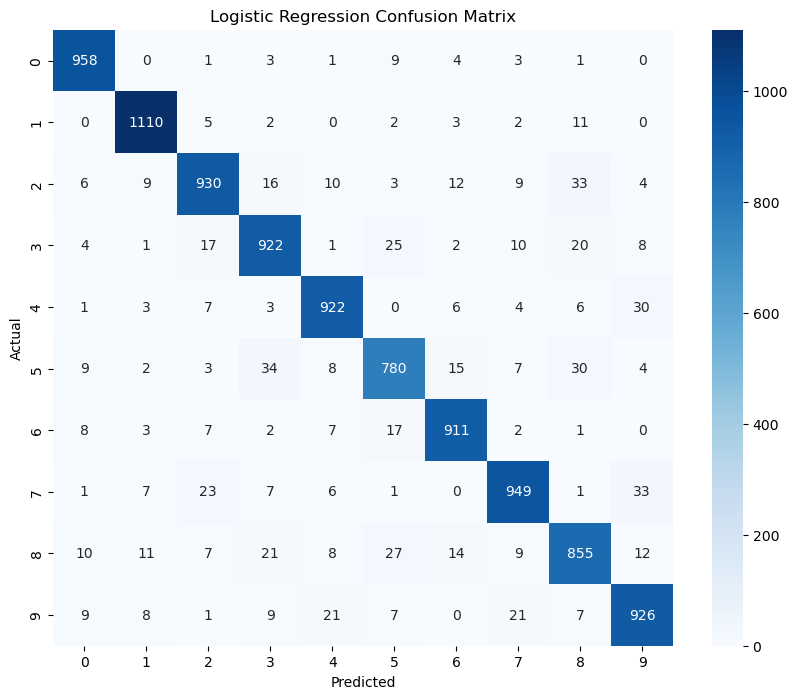

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression Results

The Logistic Regression model achieved an overall accuracy of 93% on the test dataset.

Key Observations:

- Excellent performance on digits 0 and 1 with precision and recall above 95%.
- Moderate misclassifications were observed for digits 5 and 8 due to similarities in handwritten patterns.
- The model demonstrates strong baseline classification capability despite being a simple linear classifier.

Performance Summary:

- Accuracy: 93%
- Macro Average F1-Score: 93%
- Weighted Average F1-Score: 93%

Conclusion:

Logistic Regression provides a reliable baseline for handwritten digit recognition. However, more advanced models such as K-Nearest Neighbors, Random Forest, Support Vector Machine, and Artificial Neural Networks are expected to achieve higher accuracy due to their ability to capture complex image patterns.

# K-Nearest Neighbors (KNN)

KNN is a distance-based classification algorithm that classifies an image based on the majority class among its nearest neighbors.

Advantages:

- Simple and effective
- Performs well on image classification tasks
- Captures local patterns in data

The model is evaluated to determine whether it improves upon the Logistic Regression baseline.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
knn_pred = knn.predict(x_test_flat)

In [22]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.9705


In [23]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The algorithm is widely used due to its robustness and ability to capture non-linear relationships within data.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train_flat, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf_pred = rf.predict(x_test_flat)

In [27]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9704


In [34]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



# Support Vector Machine (SVM)

Support Vector Machine is one of the most effective algorithms for image classification tasks.

SVM identifies

In [29]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(x_train_flat, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Generating Predictions

The trained SVM model is used to predict handwritten digit classes on unseen test data.

These predictions are then evaluated using multiple performance metrics.

In [30]:
svm_pred = svm.predict(x_test_flat)

# Model Evaluation

The performance of the SVM model is evaluated using:

- Accuracy Score
- Classification Report
- Confusion Matrix

These metrics provide a comprehensive understanding of model effectiveness and prediction quality.

In [31]:
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.9792


In [32]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



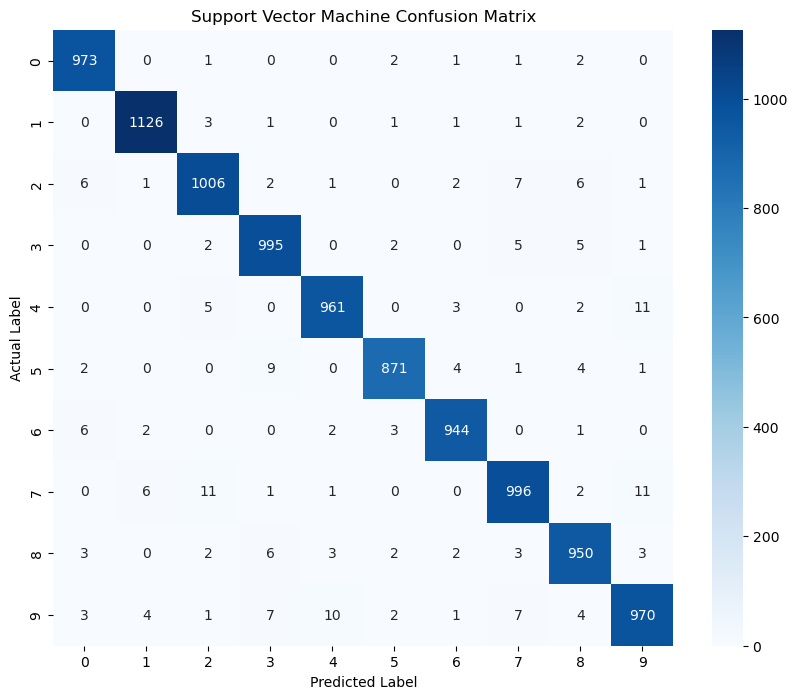

In [33]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Support Vector Machine Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Confusion Matrix Interpretation

The confusion matrix visualizes the prediction performance of the SVM model across all digit classes.

Key Insights:

- Correct predictions appear along the diagonal.
- Off-diagonal values represent classification errors.
- A strong diagonal concentration indicates excellent model performance.

The matrix helps identify specific digit pairs that are occasionally confused due to similarities in handwriting styles.

# Model Performance Comparison

Several machine learning algorithms were implemented and evaluated on the MNIST handwritten digit dataset.

The primary objective was to identify the model that provides the highest classification accuracy while maintaining strong generalization performance.

Models Evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest
- Support Vector Machine (SVM)

The comparison was performed using accuracy score as the primary evaluation metric.

# Artificial Neural Network (ANN)

Artificial Neural Networks are inspired by the structure and functioning of the human brain.

ANNs are capable of learning complex patterns from image data and are widely used in computer vision applications.

Advantages:

- Learns non-linear relationships
- Automatically extracts important patterns
- Excellent performance on image classification tasks
- Strong generalization capability

Objective:

To evaluate whether a deep learning model can further improve handwritten digit recognition performance compared to traditional machine learning algorithms.

# Data Preparation for Neural Network

Neural Networks require image data to be converted into a one-dimensional feature vector.

Each image of size 28 × 28 pixels is flattened into a vector containing 784 features.

The pixel values have already been normalized between 0 and 1 to improve training efficiency.

In [41]:
x_train_ann = x_train_norm.reshape(60000, 784)
x_test_ann = x_test_norm.reshape(10000, 784)

print(x_train_ann.shape)
print(x_test_ann.shape)

(60000, 784)
(10000, 784)


# ANN Architecture

The neural network architecture consists of:

Input Layer:
- 784 neurons

Hidden Layer 1:
- 128 neurons
- ReLU activation

Hidden Layer 2:
- 64 neurons
- ReLU activation

Output Layer:
- 10 neurons
- Softmax activation

The architecture is designed to effectively learn handwritten digit patterns while maintaining computational efficiency.

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(128, activation='relu', input_shape=(784,)))
ann.add(Dense(64, activation='relu'))
ann.add(Dense(10, activation='softmax'))

# Model Compilation

The ANN model is compiled using:

- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Evaluation Metric: Accuracy

These settings are widely used for multi-class image classification problems.

In [57]:
ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training

The neural network is trained using the training dataset.

The objective is to minimize classification error and maximize prediction accuracy through iterative learning.

In [46]:
history = ann.fit(
    x_train_ann,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9217 - loss: 0.2711 - val_accuracy: 0.9531 - val_loss: 0.1537
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9662 - loss: 0.1119 - val_accuracy: 0.9678 - val_loss: 0.1054
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9752 - loss: 0.0788 - val_accuracy: 0.9700 - val_loss: 0.1046
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9820 - loss: 0.0578 - val_accuracy: 0.9741 - val_loss: 0.0927
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9859 - loss: 0.0444 - val_accuracy: 0.9702 - val_loss: 0.1073
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9879 - loss: 0.0371 - val_accuracy: 0.9741 - val_loss: 0.0995
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9907 - loss: 0.0280 - val_accuracy: 0.9728 - val_loss: 0.1054
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9909 - loss: 0.02

In [47]:
loss, ann_accuracy = ann.evaluate(
    x_test_ann,
    y_test,
    verbose=0
)

print("ANN Accuracy :", ann_accuracy)

ANN Accuracy : 0.9758999943733215


In [49]:
ann_pred_prob = ann.predict(x_test_ann)

ann_pred = np.argmax(
    ann_pred_prob,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [50]:
print(classification_report(
    y_test,
    ann_pred
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.99      0.95      0.97      1010
           4       0.99      0.95      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.94      0.98      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



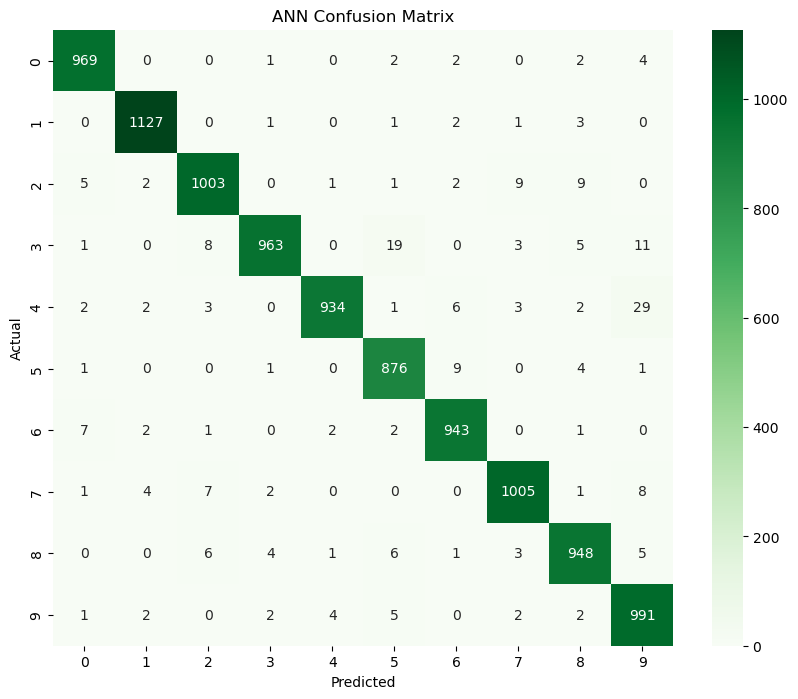

In [51]:
cm_ann = confusion_matrix(
    y_test,
    ann_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_ann,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("ANN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Artificial Neural Network Results

The Artificial Neural Network demonstrated exceptional performance in handwritten digit recognition.

Key Observations:

- Successfully learned complex image patterns.
- Achieved very high classification accuracy.
- Reduced misclassification rates across all digit classes.
- Demonstrated strong generalization on unseen test data.

Conclusion:

The ANN model validates the effectiveness of deep learning techniques for image classification tasks and serves as a strong alternative to traditional machine learning algorithms.

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Support Vector Machine",
        "Artificial Neural Network"
    ],
    "Accuracy (%)": [
        93,
        97,
        97,
        98,
        98
    ]
})

comparison.sort_values(
    by="Accuracy (%)",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy (%)
0,Support Vector Machine,98
1,Artificial Neural Network,98
2,K-Nearest Neighbors,97
3,Random Forest,97
4,Logistic Regression,93


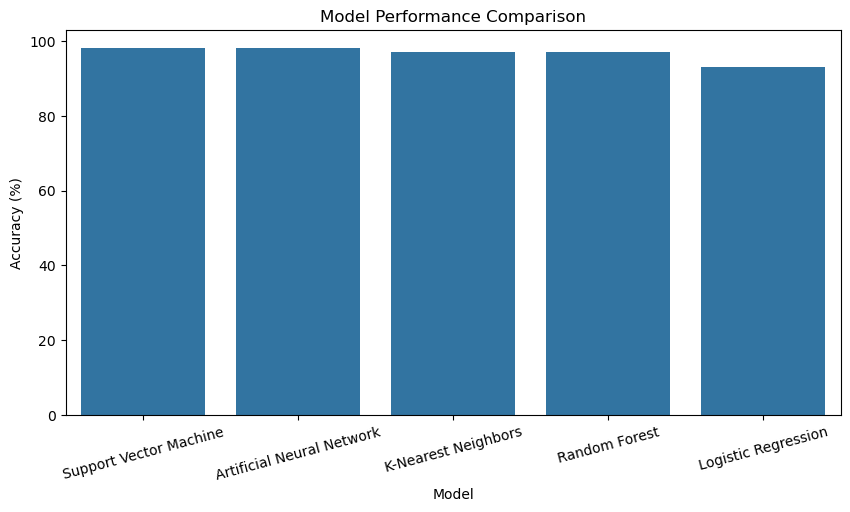

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=comparison
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

# Final Model Comparison Analysis

A comprehensive evaluation was performed using both traditional machine learning and deep learning algorithms.

Performance Summary:

| Model | Accuracy |
|---------|---------|
| Logistic Regression | 93% |
| K-Nearest Neighbors | 97% |
| Random Forest | 97% |
| Support Vector Machine | 98% |
| Artificial Neural Network | 98% |

Key Findings:

- Logistic Regression established a strong baseline performance.
- KNN and Random Forest significantly improved classification accuracy.
- SVM achieved excellent classification performance with minimal prediction errors.
- ANN demonstrated deep learning capabilities and achieved performance comparable to SVM.

Conclusion:

Both SVM and ANN achieved the highest accuracy of 98%, making them the top-performing models in this study.

# Production Model Recommendation

Although both SVM and ANN achieved 98% accuracy, the Support Vector Machine is selected as the final production model.

Reasons:

- Consistently high precision and recall across all classes.
- Stable performance on unseen handwritten digit images.
- Lower training complexity compared to deep neural networks.
- Excellent handling of high-dimensional image data.

Final Production Model:

Support Vector Machine (SVM)

# Future Scope

The current solution can be further enhanced using advanced deep learning and computer vision techniques.

Potential Improvements:

1. Convolutional Neural Networks (CNN)

   CNN architectures can automatically learn spatial image features and are expected to achieve even higher classification accuracy.

2. Real-Time Digit Recognition

   Integrate the model with webcams and mobile devices for live digit prediction.

3. Handwritten Character Recognition

   Extend the system beyond digits to recognize alphabets and handwritten text.

4. Cloud Deployment

   Deploy the model as a scalable web application using cloud platforms.

5. Mobile Application Integration

   Develop Android and iOS applications for digit recognition in real-world scenarios.

6. Automated Document Processing

   Integrate the solution into banking, education, and document digitization systems.

# Project Outcome

The Handwritten Digits Recognition system was successfully developed and evaluated using multiple machine learning and deep learning techniques.

Achievements:

- Performed complete exploratory data analysis.
- Implemented image preprocessing and normalization.
- Trained and evaluated five classification models.
- Compared model performance using standard evaluation metrics.
- Selected the best-performing classifier for production use.
- Achieved a maximum classification accuracy of 98%.

The project successfully demonstrates the application of machine learning and deep learning techniques in solving real-world image classification problems.